In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib import gridspec
import pandas as pd
import seaborn as sns

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 14,
    "axes.linewidth": 1.2,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    'grid.linestyle':    '--',
    'grid.linewidth':    0.4,
    'axes.linewidth':   0.8,
})

def bootstrap_ci_width(x, n_resamples=10):
    """Return upper 95% bootstrap CI distance from the mean."""
    result = stats.bootstrap(
        (x.dropna().values,),
        np.mean,
        confidence_level=0.95,
        n_resamples=n_resamples,
        random_state=1,
        method="percentile",
    )
    mean = np.mean(x)
    return result.confidence_interval.high - mean


def clean_axis(ax, xlabel="", ylabel=""):
    """Apply minimal Nature-style axis formatting."""
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(direction="out", length=4, width=1.1)

# Load data

In [2]:
df1 = pd.read_parquet("data_first_au.parquet")
df2 = pd.read_parquet("data_last_au.parquet")
# df['ai_prob_'] = pd.cut(df['ai_prob'], bins=10).apply(lambda x:x.mid)

In [3]:
from matplotlib import legend


colors = {
    1.0: "#CC79A7",  # Female
    0.0: "#0072B2"   # Male
}

gender_labels = {
    1.0: "Female",
    0.0: "Male"
}

markers = {
    1.0: "o",
    0.0: "s"
}

def prep_career_df(
    df,
    age_col,
    gender_col,
    outcome_col="AIProb"
):
    d = df.copy()

    d = d[
        d[gender_col].isin([0.0, 1.0]) &
        d[age_col].notna() &
        d[outcome_col].notna()
    ].copy()

    bins = [0, 2, 4, 6, 8, 10, 15, 20, 25, 30, np.inf]

    labels = [
        "0–2",
        "3–4",
        "5–6",
        "7–8",
        "9–10",
        "11–15",
        "16–20",
        "21–25",
        "26–30",
        "30+"
    ]

    d["career_bin"] = pd.cut(
        d[age_col],
        bins=bins,
        labels=labels,
        include_lowest=True,
        right=True
    )

    d["career_bin"] = pd.Categorical(
        d["career_bin"],
        categories=labels,
        ordered=True
    )

    summary = (
        d.groupby(["career_bin", gender_col], observed=True)
         .agg(
             mean=(outcome_col, "mean"),
             n=(outcome_col, "size"),
             sd=(outcome_col, "std")
         )
         .reset_index()
    )

    summary["se"] = summary["sd"] / np.sqrt(summary["n"])
    summary["low"] = summary["mean"] - 1.96 * summary["se"]
    summary["high"] = summary["mean"] + 1.96 * summary["se"]

    gap = (
        summary
        .pivot(
            index="career_bin",
            columns=gender_col,
            values="mean"
        )
        .reset_index()
    )

    gap["gap"] = gap[1.0] - gap[0.0]

    return summary, gap, labels


def clean_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.35)


def draw_career_lines(ax, summary, gender_col, title, ylabel, legend=False):
    x_order = summary["career_bin"].cat.categories

    for gender in [1.0, 0.0]:
        sub = (
            summary[summary[gender_col] == gender]
            .set_index("career_bin")
            .reindex(x_order)
            .reset_index()
        )

        x = np.arange(len(x_order))

        ax.plot(
            x,
            sub["mean"],
            marker=markers[gender],
            linewidth=0.8,
            markersize=3,
            color=colors[gender],
            label=gender_labels[gender]
        )

        ax.fill_between(
            x,
            sub["low"],
            sub["high"],
            color=colors[gender],
            alpha=0.16,
            linewidth=0
        )

    ax.set_xticks(np.arange(len(x_order)))
    ax.set_xticklabels(x_order, rotation=90, ha="right")
    ax.set_title(title)
    ax.set_xlabel("Career age")
    ax.set_ylabel(ylabel)
    if legend:
        ax.legend(frameon=False)
    clean_axis(ax)


def draw_gap_bars(ax, gap, title, ylabel):
    x_order = gap["career_bin"].cat.categories

    gap = (
        gap
        .set_index("career_bin")
        .reindex(x_order)
        .reset_index()
    )

    x = np.arange(len(x_order))

    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=1
    )

    ax.bar(
        x,
        gap["gap"],
        color="#666666",
        width=0.7
    )

    ax.set_xticks(x)
    ax.set_xticklabels(x_order, rotation=90, ha="right")
    ax.set_title(title)
    ax.set_xlabel("Career age")
    ax.set_ylabel(ylabel)
    clean_axis(ax)


In [4]:
# Prepare summaries
first_summary, first_gap, career_labels = prep_career_df(
    df1,
    age_col="first_age",
    gender_col="first_Female",
    outcome_col="AIProb"
)

last_summary, last_gap, _ = prep_career_df(
    df2,
    age_col="last_age",
    gender_col="last_Female",
    outcome_col="AIProb"
)

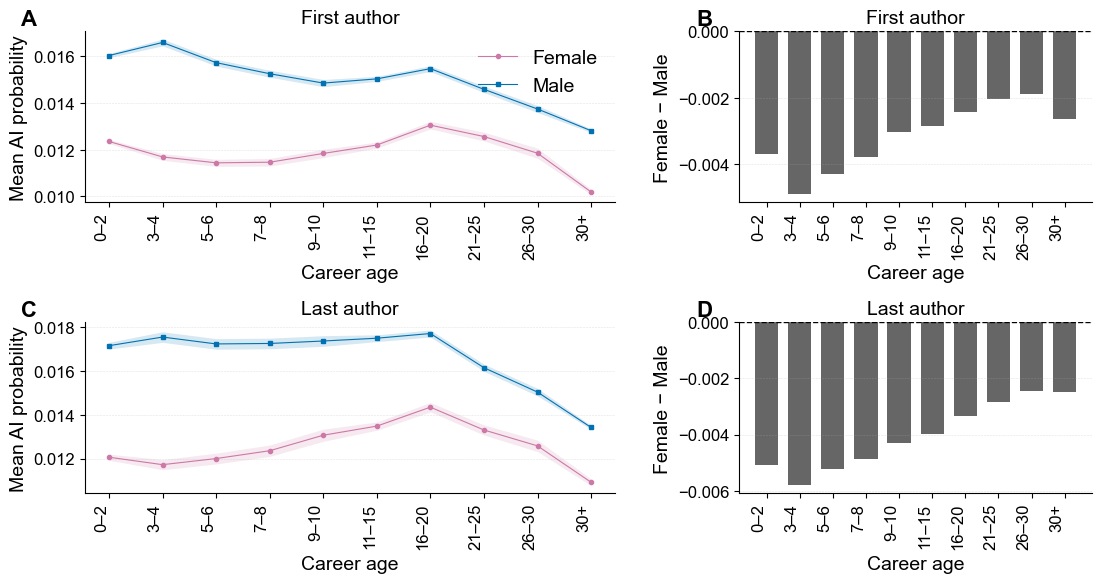

In [5]:
# Figure
fig = plt.figure(figsize=(13, 6))

gs = gridspec.GridSpec(
    2, 2,
    width_ratios=[1.5, 1],
    height_ratios=[1, 1],
    wspace=0.28,
    hspace=0.7
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

draw_career_lines(
    ax1,
    first_summary,
    gender_col="first_Female",
    title="First author",
    ylabel="Mean AI probability",
    legend=True
)

draw_gap_bars(
    ax2,
    first_gap,
    title="First author",
    ylabel="Female − Male"
)

draw_career_lines(
    ax3,
    last_summary,
    gender_col="last_Female",
    title="Last author",
    ylabel="Mean AI probability",
    legend=False
)

draw_gap_bars(
    ax4,
    last_gap,
    title="Last author",
    ylabel="Female − Male"
)


# Panel labels
for ax, label in zip(
    [ax1, ax2, ax3, ax4],
    ["A", "B", "C", "D"]
):
    ax.text(
        -0.12,
        1.13,
        label,
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold",
        va="top"
    )

plt.savefig("Data/fig2_age.pdf", bbox_inches="tight")

In [6]:
df1['Gender_entropy'].max()

0.6931471805599453